# Ablation — GPTQ + LQER: Full Quantization Pipeline

Evaluates the full advanced quantization pipeline against baseline and plain GPTQ.

| config | method | matrices | embeddings | LQER | group | asymmetric |
|---|---|---|---|---|---|---|
| Baseline | naive rounding | int8 per-row | fp16 passthrough | — | — | no |
| GPTQ int8 | GPTQ | int8 per-row | int8 per-row | — | — | no |
| GPTQ int6 | GPTQ | int6 per-row | int8 per-row | — | — | no |
| GPTQ+LQER | GPTQ | int6 group-32 | int7 per-row | rank-4 top-3 | 32 | yes |

## Goal

This notebook answers:
1. **Does the full GPTQ+LQER pipeline improve over plain GPTQ?** Comparing the round-trip BPB and quantization delta.
2. **How much does each component contribute?** Asymmetric group-wise quantization vs symmetric per-row, int7 embeddings vs int8, LQER correction vs no correction.
3. **What's the file size tradeoff?** LQER adds correction matrices; group-wise adds extra scales and zero-points. Is the BPB gain worth the storage cost?
4. **Which layers received LQER correction?** Identifying the most sensitive layers in the architecture.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib
import utils as utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

# Colors for each method
COLOR_BASELINE  = PALETTE[0]
COLOR_GPTQ      = PALETTE[1]
COLOR_GPTQ_LQER = PALETTE[2]

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\matte\_netrc.


## Original Baseline (3 seeds, reference)

In [2]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN  = df_base["final_val_bpb"].mean()
BASE_BPB_STD   = df_base["final_val_bpb"].std()
BASE_SIZE_MEAN = df_base["quant_file_bytes"].mean()

print("=" * 55)
print("ORIGINAL BASELINE  (3 seeds)")
print("=" * 55)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print(f"file size     : {BASE_SIZE_MEAN / 1e6:.2f} MB")
print("=" * 55)

ORIGINAL BASELINE  (3 seeds)
 seed  final_val_bpb  final_val_loss  quant_file_bytes
   42       1.311465        2.214354          15782427
  123       1.309002        2.210195          15785894
 1337       1.309833        2.211598          15776355

final_val_bpb : 1.3101 ± 0.0013
file size     : 15.78 MB


## Fetch All Ablation Runs

In [4]:
# --- Fetch plain GPTQ runs ---
GPTQ_PREFIX = "GPTQ_MATRICES"

gptq_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{GPTQ_PREFIX}"}},
))

gptq_rows = []
for run in gptq_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", cfg.get("quant_bits", 8))

    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    gptq_rows.append({
        "run_name":         run.name,
        "method":           f"GPTQ int{bits}",
        "seed":             cfg.get("seed"),
        "fp32_val_bpb":     fp32_bpb,
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
        "matrix_bits":      bits,
        "embed_bits":       cfg.get("embed_quant_bits", bits),
        "lqer_rank":        0,
        "lqer_top_k":       0,
        "group_size":       0,
        "asymmetric":       False,
    })

df_gptq = pd.DataFrame(gptq_rows)
print(f"Fetched {len(df_gptq)} plain GPTQ runs.")

Fetched 9 plain GPTQ runs.


In [12]:
df_gptq.head()

,run_name,method,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes,matrix_bits,embed_bits,lqer_rank,lqer_top_k,group_size,asymmetric
0,GPTQ_MATRICES_seed1337,GPTQ int6,1337,1.306296,1.364889,2.304558,11896932,6,6,0,0,0,False
1,GPTQ_MATRICES_seed42,GPTQ int6,42,1.308099,1.367217,2.308489,11897277,6,6,0,0,0,False
2,GPTQ_MATRICES_seed123,GPTQ int6,123,1.305630,1.362232,2.300072,11906305,6,6,0,0,0,False
3,GPTQ_MATRICES_seed1337,GPTQ int4,1337,1.306326,2.105418,3.554910,7850221,4,4,0,0,0,False
4,GPTQ_MATRICES_seed42,GPTQ int4,42,1.307331,2.203581,3.720654,7855540,4,4,0,0,0,False


In [5]:
# --- Fetch GPTQ+LQER runs ---
LQER_PREFIX = "GPTQ_LQER"

lqer_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{LQER_PREFIX}"}},
))

lqer_rows = []
for run in lqer_runs:
    s   = run.summary._json_dict
    cfg = run.config

    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    lqer_rows.append({
        "run_name":         run.name,
        "method":           "GPTQ+LQER",
        "seed":             cfg.get("seed"),
        "fp32_val_bpb":     fp32_bpb,
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
        "matrix_bits":      cfg.get("matrix_quant_bits", 6),
        "embed_bits":       cfg.get("embed_quant_bits", 7),
        "lqer_rank":        cfg.get("lqer_rank", 4),
        "lqer_top_k":       cfg.get("lqer_top_k", 3),
        "group_size":       cfg.get("quant_group_size", 32),
        "asymmetric":       bool(cfg.get("quant_asymmetric", 1)),
    })

df_lqer = pd.DataFrame(lqer_rows)
print(f"Fetched {len(df_lqer)} GPTQ+LQER runs.")

Fetched 3 GPTQ+LQER runs.


In [6]:
# --- Combine all runs ---
df_all = pd.concat([df_gptq, df_lqer], ignore_index=True)
df_all["delta_bpb"] = df_all["final_val_bpb"] - df_all["fp32_val_bpb"]
df_all

,run_name,method,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes,matrix_bits,embed_bits,lqer_rank,lqer_top_k,group_size,asymmetric,delta_bpb
0,GPTQ_MATRICES_seed1337,GPTQ int6,1337,1.306296,1.364889,2.304558,11896932,6,6,0,0,0,False,0.058593
1,GPTQ_MATRICES_seed42,GPTQ int6,42,1.308099,1.367217,2.308489,11897277,6,6,0,0,0,False,0.059118
2,GPTQ_MATRICES_seed123,GPTQ int6,123,1.305630,1.362232,2.300072,11906305,6,6,0,0,0,False,0.056602
3,GPTQ_MATRICES_seed1337,GPTQ int4,1337,1.306326,2.105418,3.554910,7850221,4,4,0,0,0,False,0.799092
4,GPTQ_MATRICES_seed42,GPTQ int4,42,1.307331,2.203581,3.720654,7855540,4,4,0,0,0,False,0.896250
5,GPTQ_MATRICES_seed123,GPTQ int4,123,1.305189,2.144190,3.620376,7868664,4,4,0,0,0,False,0.839002
6,GPTQ_MATRICES_seed1337,GPTQ int8,1337,1.306735,1.310361,2.212490,15767242,8,8,0,0,0,False,0.003626
7,GPTQ_MATRICES_seed42,GPTQ int8,42,1.307448,1.311094,2.213727,15773851,8,8,0,0,0,False,0.003646
8,GPTQ_MATRICES_seed123,GPTQ int8,123,1.305504,1.309179,2.210494,15783429,8,8,0,0,0,False,0.003675
9,GPTQ_LQER_int6_int7_rank4_top3_group32_asym_se...,GPTQ+LQER,1337,1.306359,1.358582,2.293908,13915509,6,7,4,3,32,True,0.052222


### Main comparison: Baseline vs GPTQ vs GPTQ+LQER

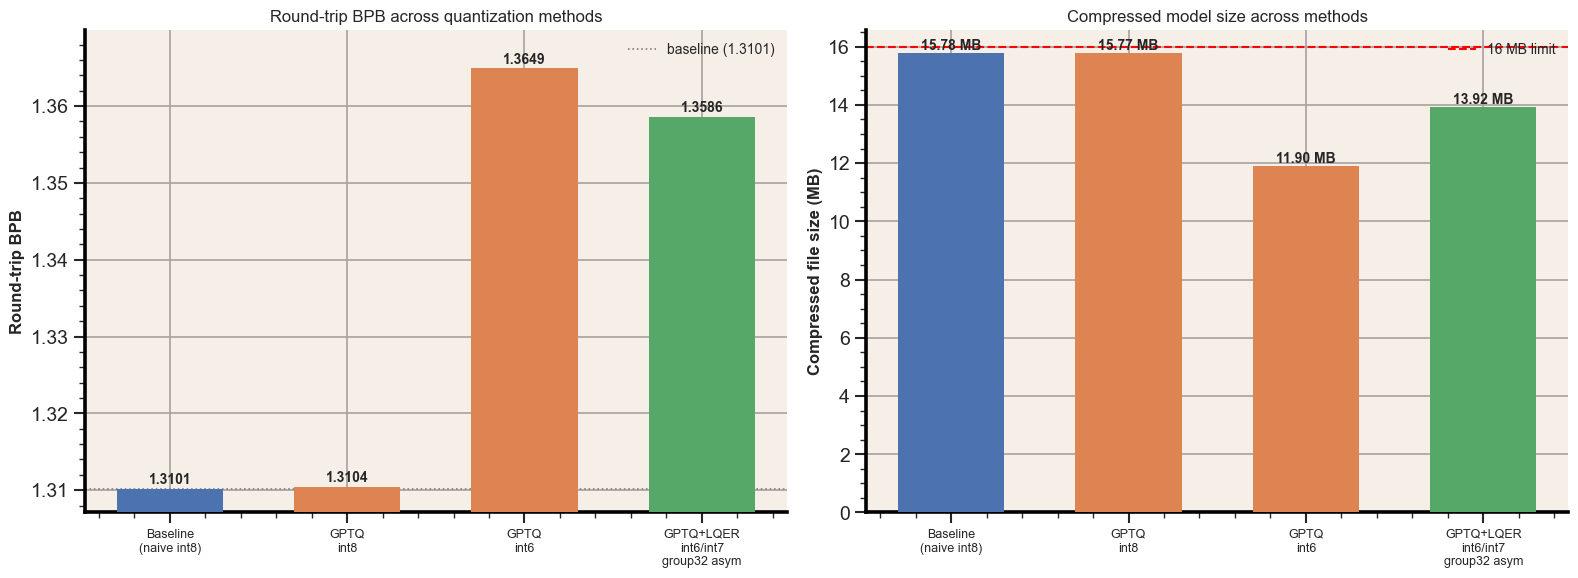

In [7]:
# Build comparison rows: baseline, best GPTQ int8, best GPTQ int6, GPTQ+LQER
comparison_methods = []
comparison_bpb = []
comparison_size = []
comparison_delta = []
comparison_colors = []

# Baseline
comparison_methods.append("Baseline\n(naive int8)")
comparison_bpb.append(BASE_BPB_MEAN)
comparison_size.append(BASE_SIZE_MEAN / 1e6)
comparison_delta.append(0.0)  # reference
comparison_colors.append(COLOR_BASELINE)

# GPTQ int8
gptq8 = df_gptq[df_gptq["matrix_bits"] == 8]
if not gptq8.empty:
    row = gptq8.iloc[0]
    comparison_methods.append("GPTQ\nint8")
    comparison_bpb.append(row["final_val_bpb"])
    comparison_size.append(row["quant_file_bytes"] / 1e6)
    comparison_delta.append(row["final_val_bpb"] - BASE_BPB_MEAN)
    comparison_colors.append(COLOR_GPTQ)

# GPTQ int6
gptq6 = df_gptq[df_gptq["matrix_bits"] == 6]
if not gptq6.empty:
    row = gptq6.iloc[0]
    comparison_methods.append("GPTQ\nint6")
    comparison_bpb.append(row["final_val_bpb"])
    comparison_size.append(row["quant_file_bytes"] / 1e6)
    comparison_delta.append(row["final_val_bpb"] - BASE_BPB_MEAN)
    comparison_colors.append(COLOR_GPTQ)

# GPTQ+LQER
if not df_lqer.empty:
    row = df_lqer.iloc[0]
    comparison_methods.append("GPTQ+LQER\nint6/int7\ngroup32 asym")
    comparison_bpb.append(row["final_val_bpb"])
    comparison_size.append(row["quant_file_bytes"] / 1e6)
    comparison_delta.append(row["final_val_bpb"] - BASE_BPB_MEAN)
    comparison_colors.append(COLOR_GPTQ_LQER)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_methods))

# --- Round-trip BPB ---
ax = axes[0]
bars = ax.bar(x, comparison_bpb, color=comparison_colors, width=0.6, zorder=3)
for i, (method, bpb) in enumerate(zip(comparison_methods, comparison_bpb)):
    ax.text(i, bpb + 0.0003, f"{bpb:.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(x)
ax.set_xticklabels(comparison_methods, fontsize=9)
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("Round-trip BPB across quantization methods", fontsize=12)
ax.legend(fontsize=10)
ymin = min(comparison_bpb) - 0.003
ymax = max(comparison_bpb) + 0.005
ax.set_ylim(ymin, ymax)

# --- Compressed file size ---
ax = axes[1]
bars = ax.bar(x, comparison_size, color=comparison_colors, width=0.6, zorder=3)
for i, (method, mb) in enumerate(zip(comparison_methods, comparison_size)):
    ax.text(i, mb + 0.03, f"{mb:.2f} MB", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.axhline(16.0, color="red", linewidth=1.5, linestyle="--",
           label="16 MB limit")
ax.set_xticks(x)
ax.set_xticklabels(comparison_methods, fontsize=9)
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("Compressed model size across methods", fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout(pad=1.5)
plt.show()

### Quantization damage (delta) comparison

KeyError: 'delta_bpb'

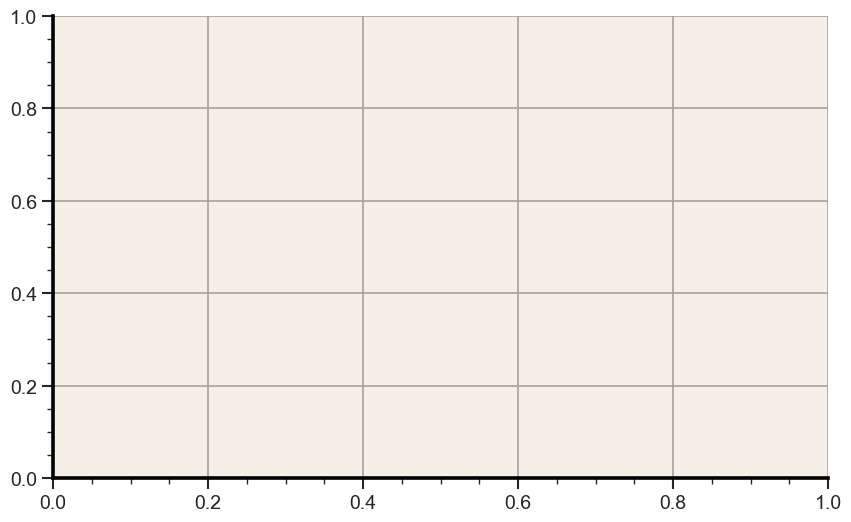

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Collect deltas for all methods that have fp32 BPB
delta_methods = []
delta_values = []
delta_colors = []

for _, row in df_gptq.iterrows():
    if pd.notna(row["delta_bpb"]):
        delta_methods.append(row["method"])
        delta_values.append(row["delta_bpb"])
        delta_colors.append(COLOR_GPTQ)

for _, row in df_lqer.iterrows():
    if pd.notna(row["delta_bpb"]):
        delta_methods.append(row["method"])
        delta_values.append(row["delta_bpb"])
        delta_colors.append(COLOR_GPTQ_LQER)

x = np.arange(len(delta_methods))
ax.bar(x, delta_values, color=delta_colors, width=0.6, zorder=3)
for i, (m, d) in enumerate(zip(delta_methods, delta_values)):
    ax.text(i, d + 0.0002, f"{d:+.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.axhline(0.0, color="grey", linewidth=1.2, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels(delta_methods, fontsize=10)
ax.set_ylabel("Δ BPB (quantization damage)", fontsize=12)
ax.set_title("Quantization damage: GPTQ vs GPTQ+LQER", fontsize=12)
plt.tight_layout(pad=1.5)
plt.show()

### BPB vs compressed size tradeoff (all methods)

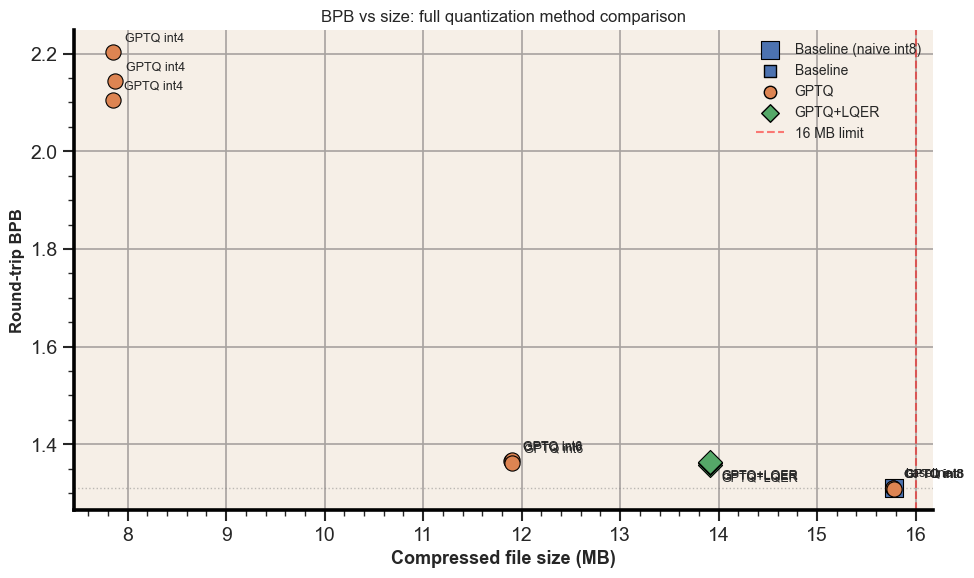

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline
ax.scatter(BASE_SIZE_MEAN / 1e6, BASE_BPB_MEAN,
           color=COLOR_BASELINE, s=150, zorder=5, marker="s",
           edgecolors="black", linewidth=0.8, label="Baseline (naive int8)")
ax.annotate("baseline",
            (BASE_SIZE_MEAN / 1e6, BASE_BPB_MEAN),
            textcoords="offset points", xytext=(8, 8), fontsize=9)

# GPTQ runs
for _, row in df_gptq.iterrows():
    ax.scatter(row["quant_file_bytes"] / 1e6, row["final_val_bpb"],
               color=COLOR_GPTQ, s=120, zorder=5, marker="o",
               edgecolors="black", linewidth=0.8)
    ax.annotate(row["method"],
                (row["quant_file_bytes"] / 1e6, row["final_val_bpb"]),
                textcoords="offset points", xytext=(8, 8), fontsize=9)

# GPTQ+LQER runs
for _, row in df_lqer.iterrows():
    ax.scatter(row["quant_file_bytes"] / 1e6, row["final_val_bpb"],
               color=COLOR_GPTQ_LQER, s=150, zorder=5, marker="D",
               edgecolors="black", linewidth=0.8)
    ax.annotate("GPTQ+LQER",
                (row["quant_file_bytes"] / 1e6, row["final_val_bpb"]),
                textcoords="offset points", xytext=(8, -12), fontsize=9)

# Legend entries
ax.scatter([], [], color=COLOR_BASELINE, s=80, marker="s", edgecolors="black", label="Baseline")
ax.scatter([], [], color=COLOR_GPTQ, s=80, marker="o", edgecolors="black", label="GPTQ")
ax.scatter([], [], color=COLOR_GPTQ_LQER, s=80, marker="D", edgecolors="black", label="GPTQ+LQER")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.0, linestyle=":", alpha=0.5)
ax.axvline(16.0, color="red", linewidth=1.5, linestyle="--", alpha=0.5, label="16 MB limit")

ax.set_xlabel("Compressed file size (MB)", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("BPB vs size: full quantization method comparison", fontsize=12)
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout(pad=1.5)
plt.show()

### GPTQ+LQER configuration details

In [13]:
if not df_lqer.empty:
    print("GPTQ+LQER Configuration")
    print("=" * 55)
    for _, row in df_lqer.iterrows():
        print(f"Run:            {row['run_name']}")
        print(f"Matrix bits:    int{row['matrix_bits']}")
        print(f"Embed bits:     int{row['embed_bits']}")
        print(f"Group size:     {row['group_size']}")
        print(f"Asymmetric:     {row['asymmetric']}")
        print(f"LQER rank:      {row['lqer_rank']}")
        print(f"LQER top-k:     {row['lqer_top_k']}")
        print(f"Round-trip BPB: {row['final_val_bpb']:.4f}")
        print(f"File size:      {row['quant_file_bytes'] / 1e6:.2f} MB")
        print("-" * 55)

GPTQ+LQER Configuration
Run:            GPTQ_LQER_int6_int7_rank4_top3_group32_asym_seed1337
Matrix bits:    int6
Embed bits:     int7
Group size:     32
Asymmetric:     True
LQER rank:      4
LQER top-k:     3
Round-trip BPB: 1.3586
File size:      13.92 MB
-------------------------------------------------------
Run:            GPTQ_LQER_int6_int7_rank4_top3_group32_asym_seed42
Matrix bits:    int6
Embed bits:     int7
Group size:     32
Asymmetric:     True
LQER rank:      4
LQER top-k:     3
Round-trip BPB: 1.3626
File size:      13.91 MB
-------------------------------------------------------
Run:            GPTQ_LQER_int6_int7_rank4_top3_group32_asym_seed123
Matrix bits:    int6
Embed bits:     int7
Group size:     32
Asymmetric:     True
LQER rank:      4
LQER top-k:     3
Round-trip BPB: 1.3641
File size:      13.92 MB
-------------------------------------------------------


### Summary table

In [14]:
rows_summary = []

# Baseline
rows_summary.append({
    "method":          "Baseline (naive int8)",
    "matrices":        "int8 per-row sym",
    "embeddings":      "fp16 passthrough",
    "LQER":            "—",
    "val_bpb":         BASE_BPB_MEAN,
    "Δ vs baseline":   0.0,
    "delta_bpb":       float("nan"),
    "file_size_MB":    BASE_SIZE_MEAN / 1e6,
})

# GPTQ runs
for _, row in df_gptq.iterrows():
    rows_summary.append({
        "method":          row["method"],
        "matrices":        f"int{row['matrix_bits']} per-row sym",
        "embeddings":      f"int{row['embed_bits']} per-row",
        "LQER":            "—",
        "val_bpb":         row["final_val_bpb"],
        "Δ vs baseline":   row["final_val_bpb"] - BASE_BPB_MEAN,
        "delta_bpb":       row.get("delta_bpb", float("nan")),
        "file_size_MB":    row["quant_file_bytes"] / 1e6,
    })

# GPTQ+LQER runs
for _, row in df_lqer.iterrows():
    asym_str = "asym" if row["asymmetric"] else "sym"
    rows_summary.append({
        "method":          "GPTQ+LQER",
        "matrices":        f"int{row['matrix_bits']} g{row['group_size']} {asym_str}",
        "embeddings":      f"int{row['embed_bits']} per-row sym",
        "LQER":            f"rank-{row['lqer_rank']} top-{row['lqer_top_k']}",
        "val_bpb":         row["final_val_bpb"],
        "Δ vs baseline":   row["final_val_bpb"] - BASE_BPB_MEAN,
        "delta_bpb":       row.get("delta_bpb", float("nan")),
        "file_size_MB":    row["quant_file_bytes"] / 1e6,
    })

df_summary = pd.DataFrame(rows_summary)
df_summary["val_bpb"]       = df_summary["val_bpb"].map(lambda x: f"{x:.4f}")
df_summary["Δ vs baseline"] = df_summary["Δ vs baseline"].map(lambda x: f"{x:+.4f}")
df_summary["delta_bpb"]     = df_summary["delta_bpb"].map(lambda x: f"{x:+.4f}" if not np.isnan(x) else "—")
df_summary["file_size_MB"]  = df_summary["file_size_MB"].map(lambda x: f"{x:.2f}")

print(df_summary.to_string(index=False))

               method         matrices       embeddings         LQER val_bpb Δ vs baseline delta_bpb file_size_MB
Baseline (naive int8) int8 per-row sym fp16 passthrough            —  1.3101       +0.0000         —        15.78
            GPTQ int6 int6 per-row sym     int6 per-row            —  1.3649       +0.0548         —        11.90
            GPTQ int6 int6 per-row sym     int6 per-row            —  1.3672       +0.0571         —        11.90
            GPTQ int6 int6 per-row sym     int6 per-row            —  1.3622       +0.0521         —        11.91
            GPTQ int4 int4 per-row sym     int4 per-row            —  2.1054       +0.7953         —         7.85
            GPTQ int4 int4 per-row sym     int4 per-row            —  2.2036       +0.8935         —         7.86
            GPTQ int4 int4 per-row sym     int4 per-row            —  2.1442       +0.8341         —         7.87
            GPTQ int8 int8 per-row sym     int8 per-row            —  1.3104       +0.00

In [15]:
# Key findings
print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)

if not df_lqer.empty:
    lqer_row = df_lqer.iloc[0]
    lqer_bpb = lqer_row["final_val_bpb"]
    lqer_size = lqer_row["quant_file_bytes"] / 1e6

    # vs baseline
    diff_base = lqer_bpb - BASE_BPB_MEAN
    print(f"\nGPTQ+LQER vs Baseline:")
    print(f"  BPB:  {lqer_bpb:.4f} vs {BASE_BPB_MEAN:.4f} ({diff_base:+.4f})")
    print(f"  Size: {lqer_size:.2f} MB vs {BASE_SIZE_MEAN / 1e6:.2f} MB")

    # vs best GPTQ
    if not df_gptq.empty:
        best_gptq = df_gptq.loc[df_gptq["final_val_bpb"].idxmin()]
        diff_gptq = lqer_bpb - best_gptq["final_val_bpb"]
        print(f"\nGPTQ+LQER vs best GPTQ ({best_gptq['method']}):")
        print(f"  BPB:  {lqer_bpb:.4f} vs {best_gptq['final_val_bpb']:.4f} ({diff_gptq:+.4f})")
        print(f"  Size: {lqer_size:.2f} MB vs {best_gptq['quant_file_bytes'] / 1e6:.2f} MB")

    # vs GPTQ at same bitwidth (int6)
    gptq6 = df_gptq[df_gptq["matrix_bits"] == 6]
    if not gptq6.empty:
        g6_row = gptq6.iloc[0]
        diff_g6 = lqer_bpb - g6_row["final_val_bpb"]
        size_diff = lqer_size - g6_row["quant_file_bytes"] / 1e6
        print(f"\nGPTQ+LQER vs GPTQ int6 (same base bitwidth):")
        print(f"  BPB:  {lqer_bpb:.4f} vs {g6_row['final_val_bpb']:.4f} ({diff_g6:+.4f})")
        print(f"  Size: {lqer_size:.2f} MB vs {g6_row['quant_file_bytes'] / 1e6:.2f} MB ({size_diff:+.2f} MB)")
        if diff_g6 < 0:
            print(f"  → LQER recovers {-diff_g6:.4f} BPB at a cost of {size_diff:.2f} MB")

    # Under 16 MB check
    print(f"\n16 MB budget check: {lqer_size:.2f} MB → {'✓ FITS' if lqer_size <= 16.0 else '✗ EXCEEDS'}")


KEY FINDINGS

GPTQ+LQER vs Baseline:
  BPB:  1.3586 vs 1.3101 (+0.0485)
  Size: 13.92 MB vs 15.78 MB

GPTQ+LQER vs best GPTQ (GPTQ int8):
  BPB:  1.3586 vs 1.3092 (+0.0494)
  Size: 13.92 MB vs 15.78 MB

GPTQ+LQER vs GPTQ int6 (same base bitwidth):
  BPB:  1.3586 vs 1.3649 (-0.0063)
  Size: 13.92 MB vs 11.90 MB (+2.02 MB)
  → LQER recovers 0.0063 BPB at a cost of 2.02 MB

16 MB budget check: 13.92 MB → ✓ FITS
